# DeepWalk neuronal — GCN enrichi (features structurelles)
Feature matrix riche (5 features) + GCN 3 couches + loss skip-gram

**v5** — Projecteur 32D→2D remplacé par version **supervisée** (contrastive + centroid loss sur les ancres Nodes.csv)


## 1 — Construction de la feature matrix enrichie

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected
from torch_cluster import random_walk
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


In [4]:
# ── Chargement & encodage ─────────────────────────────────────────────────────
DATA_PATH = 'part_01.csv'
df = pd.read_csv(DATA_PATH)
df_agg = df.groupby(['user_id', 'original_author'], as_index=False)['nb_retweeted'].sum()

le = LabelEncoder()
all_ids = pd.concat([df_agg['user_id'], df_agg['original_author']]).unique()
le.fit(all_ids)
df_agg['src'] = le.transform(df_agg['user_id'])
df_agg['dst'] = le.transform(df_agg['original_author'])
N = len(le.classes_)
np.save('label_encoder_classes.npy', le.classes_)

print(f'Nœuds : {N:,}  |  Arcs : {len(df_agg):,}')

Nœuds : 139,229  |  Arcs : 214,148


In [5]:
# ── Construction du graphe NetworkX (non-orienté, pondéré) ────────────────────
print('Construction du graphe NetworkX...')
G_nx = nx.Graph()
G_nx.add_nodes_from(range(N))
G_nx.add_weighted_edges_from(
    zip(df_agg['src'], df_agg['dst'], df_agg['nb_retweeted'])
)
print(f'Graphe : {G_nx.number_of_nodes():,} nœuds, {G_nx.number_of_edges():,} arcs')

Construction du graphe NetworkX...
Graphe : 139,229 nœuds, 214,148 arcs


In [6]:
# ── Calcul des features structurelles ────────────────────────────────────────
# Toutes vectorisées ou via dict NetworkX pour éviter les boucles Python
print('Calcul des features structurelles (2-4 min)...')

nodes = list(range(N))

# 1. Degré (nombre de voisins)
degree_dict = dict(G_nx.degree())
degree = np.array([degree_dict.get(i, 0) for i in nodes], dtype=float)

# 2. Force (somme des poids des arcs — nb_retweeted)
strength_dict = dict(G_nx.degree(weight='weight'))
strength = np.array([strength_dict.get(i, 0) for i in nodes], dtype=float)

# 3. Coefficient de clustering local
# Mesure si les voisins d'un nœud se connaissent entre eux → signature de communauté
print('  → clustering...')
clustering_dict = nx.clustering(G_nx)
clustering = np.array([clustering_dict.get(i, 0) for i in nodes], dtype=float)

# 4. Degré moyen des voisins (ego-network density)
# Un nœud dans une communauté dense a des voisins eux-mêmes bien connectés
print('  → average neighbor degree...')
avg_neighbor_deg_dict = nx.average_neighbor_degree(G_nx)
avg_neighbor_deg = np.array([avg_neighbor_deg_dict.get(i, 0) for i in nodes], dtype=float)

# 5. Log-force normalisée (capture les hubs sans les écraser)
log_strength = np.log1p(strength)

# 6. Ratio force/degré (poids moyen par arc — intensité de la relation)
ratio_strength_degree = np.where(degree > 0, strength / degree, 0)

print('Features calculées.')
features_raw = np.column_stack([
    degree,
    clustering,
    avg_neighbor_deg,
    log_strength,
    ratio_strength_degree
])
print(f'Shape features : {features_raw.shape}')  # (N, 5)

Calcul des features structurelles (2-4 min)...
  → clustering...
  → average neighbor degree...
Features calculées.
Shape features : (139229, 5)


In [7]:
# ── Normalisation StandardScaler ──────────────────────────────────────────────
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_raw)
x_rich = torch.tensor(features_scaled, dtype=torch.float)

print(f'Feature matrix : {x_rich.shape}')
print(pd.DataFrame(features_raw, columns=[
    'degree','clustering','avg_neighbor_deg','log_strength','ratio_str_deg'
]).describe().round(3))

Feature matrix : torch.Size([139229, 5])
           degree  clustering  avg_neighbor_deg  log_strength  ratio_str_deg
count  139229.000  139229.000        139229.000    139229.000     139229.000
mean        3.076       0.024           355.605         2.475          9.127
std        24.325       0.127           615.861         1.041         16.297
min         1.000       0.000             1.000         1.099          2.000
25%         1.000       0.000             5.000         1.946          4.000
50%         1.000       0.000            60.000         2.398          8.000
75%         2.000       0.000           408.000         2.944         10.000
max      2789.000       1.000          2789.000        10.999       2497.000


In [8]:
# ── edge_index PyG (non-orienté) ─────────────────────────────────────────────
edge_index_dir = torch.tensor(
    np.stack([df_agg['src'].values, df_agg['dst'].values]), dtype=torch.long
)
edge_index = to_undirected(edge_index_dir, num_nodes=N)
print(f'edge_index : {edge_index.shape}')

edge_index : torch.Size([2, 428296])


## 2 — Architecture GCN enrichie

In [10]:
class GCNEmbedder(nn.Module):
    """
    GCN 3 couches avec BatchNorm et skip connections.
    Les skip connections permettent au gradient de circuler
    même si une couche n'apporte pas d'information utile.
    Sortie : embeddings normalisés L2 (N × out_dim)
    """
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim,      hidden_dim)
        self.conv2 = GCNConv(hidden_dim,  hidden_dim)
        self.conv3 = GCNConv(hidden_dim,  out_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        # Projection pour la skip connection (in_dim → hidden_dim)
        self.skip  = nn.Linear(in_dim, hidden_dim, bias=False)

    def forward(self, x, edge_index):
        # Couche 1
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h1 = h1 + self.skip(x)          # skip connection
        h1 = F.dropout(h1, p=0.2, training=self.training)
        # Couche 2
        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h2 = h2 + h1                     # skip connection
        h2 = F.dropout(h2, p=0.2, training=self.training)
        # Couche 3 — projection finale
        out = self.conv3(h2, edge_index)
        return F.normalize(out, p=2, dim=1)  # L2 norm


# Hyperparamètres
IN_DIM          = x_rich.shape[1]   # 5
HIDDEN_DIM      = 128
EMBED_DIM       = 32
WALK_LENGTH     = 20
CONTEXT_SIZE    = 5
WALKS_PER_NODE  = 5
NEG_SAMPLES     = 10
EPOCHS          = 200
LR              = 0.01
NODES_PER_BATCH = 500
MAX_PAIRS       = 4096

model     = GCNEmbedder(IN_DIM, HIDDEN_DIM, EMBED_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=1, epochs=EPOCHS,
    pct_start=0.1
)

x_dev  = x_rich.to(device)
ei_dev = edge_index.to(device)
row    = ei_dev[0]
col    = ei_dev[1]

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres : {total_params:,}')
print(model)

Paramètres : 22,560
GCNEmbedder(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 32)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Linear(in_features=5, out_features=128, bias=False)
)


## 3 — Loss skip-gram

In [11]:
def skipgram_loss(z, pos_pairs, neg_pairs):
    pos_score = (z[pos_pairs[:, 0]] * z[pos_pairs[:, 1]]).sum(dim=1)
    neg_score = (z[neg_pairs[:, 0]] * z[neg_pairs[:, 1]]).sum(dim=1)
    loss_pos  = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
    loss_neg  = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
    return loss_pos + loss_neg


def generate_pairs(walk_tensor, context_size, neg_samples, n_nodes):
    pos_pairs = []
    num_walks, wlen = walk_tensor.shape
    for i in range(wlen):
        center = walk_tensor[:, i]
        for j in range(max(0, i - context_size), min(wlen, i + context_size + 1)):
            if j == i:
                continue
            pos_pairs.append(torch.stack([center, walk_tensor[:, j]], dim=1))
    pos_pairs = torch.cat(pos_pairs, dim=0)
    n = pos_pairs.shape[0]
    neg_ctx   = torch.randint(0, n_nodes, (n * neg_samples,), device=pos_pairs.device)
    neg_src   = pos_pairs[:, 0].repeat_interleave(neg_samples)
    neg_pairs = torch.stack([neg_src, neg_ctx], dim=1)
    return pos_pairs, neg_pairs

print('Fonctions définies.')

Fonctions définies.


## 4 — Entraînement

In [13]:
history = []
print(f"{'Epoch':>6}  {'Loss':>8}")
print('-' * 18)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0
    node_perm  = torch.randperm(N, device=device)

    # ── z détaché : utilisé pour calculer les scores des paires ─────────────
    # Le gradient NE passe PAS par z à chaque batch intermédiaire
    # → pas de conflit avec optimizer.step()
    with torch.no_grad():
        z_detached = model(x_dev, ei_dev)  # (N, 32) — pas de graphe de calcul

    accum_loss = torch.tensor(0.0, device=device, requires_grad=False)

    for batch_start in range(0, N, NODES_PER_BATCH):
        batch_nodes = node_perm[batch_start: batch_start + NODES_PER_BATCH]
        start = batch_nodes.repeat(WALKS_PER_NODE)
        walks = random_walk(row, col, start, walk_length=WALK_LENGTH)

        pos_pairs, neg_pairs = generate_pairs(walks, CONTEXT_SIZE, NEG_SAMPLES, N)

        if pos_pairs.shape[0] > MAX_PAIRS:
            idx       = torch.randperm(pos_pairs.shape[0], device=device)[:MAX_PAIRS]
            pos_pairs = pos_pairs[idx]
            neg_pairs = neg_pairs[idx.repeat_interleave(NEG_SAMPLES)[:MAX_PAIRS * NEG_SAMPLES]]

        # Score sur z détaché — pas de gradient ici
        loss_val = skipgram_loss(z_detached, pos_pairs, neg_pairs)
        accum_loss = accum_loss + loss_val.detach()
        n_batches += 1
        del walks, pos_pairs, neg_pairs

    # ── Un seul forward + backward propre à la fin de l'epoch ───────────────
    optimizer.zero_grad()
    z = model(x_dev, ei_dev)  # forward avec graphe de calcul

    # On ré-échantillonne un batch représentatif pour le backward
    sample_nodes = torch.randperm(N, device=device)[:NODES_PER_BATCH * 4]
    start_sample = sample_nodes.repeat(WALKS_PER_NODE)
    walks_sample = random_walk(row, col, start_sample, walk_length=WALK_LENGTH)
    pos_s, neg_s = generate_pairs(walks_sample, CONTEXT_SIZE, NEG_SAMPLES, N)

    if pos_s.shape[0] > MAX_PAIRS:
        idx   = torch.randperm(pos_s.shape[0], device=device)[:MAX_PAIRS]
        pos_s = pos_s[idx]
        neg_s = neg_s[idx.repeat_interleave(NEG_SAMPLES)[:MAX_PAIRS * NEG_SAMPLES]]

    loss_grad = skipgram_loss(z, pos_s, neg_s)
    loss_grad.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    epoch_loss = (accum_loss / n_batches).item()
    history.append(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {epoch_loss:>8.4f}')

print('\nEntraînement terminé.')

 Epoch      Loss
------------------
     1    1.3506
    10    1.1470
    20    1.1121
    30    1.0974
    40    1.0925
    50    1.0891
    60    1.0853
    70    1.0839
    80    1.0832
    90    1.0814
   100    1.0796
   110    1.0792
   120    1.0777
   130    1.0771
   140    1.0770
   150    1.0759
   160    1.0755
   170    1.0760
   180    1.0751
   190    1.0748
   200    1.0747

Entraînement terminé.


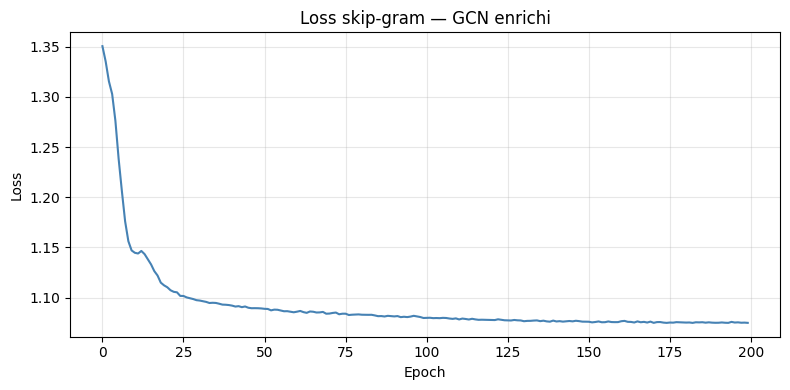

In [14]:
# ── Courbe de loss ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history, color='steelblue')
plt.title('Loss skip-gram — GCN enrichi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — Embeddings, clustering & visualisation

In [16]:
model.eval()
with torch.no_grad():
    z_final = model(x_dev, ei_dev).cpu().numpy()  # (N, 32)

np.save('embeddings_gcn_rich_01.npy', z_final)
print(f'Embeddings sauvegardés : {z_final.shape}')

Embeddings sauvegardés : (137876, 32)


In [17]:
# ── K-Means k=2 ───────────────────────────────────────────────────────────────
kmeans        = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(z_final)

idx_sil = np.random.choice(N, size=min(10000, N), replace=False)
sil     = silhouette_score(z_final[idx_sil], cluster_labels[idx_sil])

print(f'Cluster 0 : {(cluster_labels==0).sum():,} nœuds')
print(f'Cluster 1 : {(cluster_labels==1).sum():,} nœuds')
print(f'Silhouette : {sil:.4f}')

NameError: name 'z_final' is not defined

## 6 — Réduction GCN 32D → 2D (projecteur supervisé)


In [11]:
"""
# ─────────────────────────────────────────────────────────────
# Variables nécessaires pour la validation finale
# ─────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# nombre de nœuds
N = z32_input.shape[0]

# ─────────────────────────────────────────────────────────────
# Projection 2D finale du projecteur supervisé
# ─────────────────────────────────────────────────────────────

projector.eval()

with torch.no_grad():
    z_2d_tensor = projector(z32_tensor, ei_dev)

# numpy
z_2d = z_2d_tensor.cpu().numpy()

# embeddings utilisés pour le clustering
embeddings_2d = z_2d

# ─────────────────────────────────────────────────────────────
# KMeans sur la projection 2D
# ─────────────────────────────────────────────────────────────

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(embeddings_2d)

print("Clusters KMeans créés :", np.unique(cluster_labels))
print("Shape z_2d :", z_2d.shape)
print("Nombre de labels :", len(cluster_labels))
"""

'\n# ─────────────────────────────────────────────────────────────\n# Variables nécessaires pour la validation finale\n# ─────────────────────────────────────────────────────────────\n\nfrom sklearn.cluster import KMeans\nfrom sklearn.manifold import TSNE\n\n# nombre de nœuds\nN = z32_input.shape[0]\n\n# ─────────────────────────────────────────────────────────────\n# Projection 2D finale du projecteur supervisé\n# ─────────────────────────────────────────────────────────────\n\nprojector.eval()\n\nwith torch.no_grad():\n    z_2d_tensor = projector(z32_tensor, ei_dev)\n\n# numpy\nz_2d = z_2d_tensor.cpu().numpy()\n\n# embeddings utilisés pour le clustering\nembeddings_2d = z_2d\n\n# ─────────────────────────────────────────────────────────────\n# KMeans sur la projection 2D\n# ─────────────────────────────────────────────────────────────\n\nkmeans = KMeans(\n    n_clusters=2,\n    random_state=42,\n    n_init=20\n)\n\ncluster_labels = kmeans.fit_predict(embeddings_2d)\n\nprint("Clusters

In [12]:
print("démarrage")
# Encode les arêtes avec le même LabelEncoder
src_reload = le.transform(df_agg['user_id'].astype(str))
dst_reload = le.transform(df_agg['original_author'].astype(str))

edge_index_dir = torch.tensor(np.stack([src_reload, dst_reload]), dtype=torch.long)
ei_dev = to_undirected(edge_index_dir, num_nodes=len(le.classes_)).to(device)

print(f'ei_dev reconstruit : {ei_dev.shape}  →  {ei_dev.shape[1]:,} arêtes')

démarrage
ei_dev reconstruit : torch.Size([2, 428296])  →  428,296 arêtes


démarrage
Ancres totales trouvées : 1410
  classe 0 : 536
  classe 1 : 874

Split ancres :
  Train (20%) : 282  (cl0=107, cl1=175)
  Eval  (80%) : 1,128  (cl0=429, cl1=699)

Entraînement supervisé sur 20% des ancres (200 epochs)...
 Epoch      Loss   Contrast    Sépar.    Spread    Dist_c
------------------------------------------------------------

=== DEBUG NaN ===
z32_tensor  — shape: torch.Size([139229, 32]), has_nan: False, min: -0.6414, max: 0.6133
anc_idx_train  — shape: torch.Size([282]), max_idx: 138681, N_nodes: 139229
anc_labels_train — unique: [0, 1], n_class0: 107, n_class1: 175
z2d forward  — shape: torch.Size([139229, 2]), has_nan: False, min: -2.4963, max: 0.9472

Loss epoch 1  — 28.492798
  contrast            : 17.669598
  cohesion            : 0.580452
  separation          : 7.801643
  spread              : 1.220552
  dist_centroids      : 1.198357

z0 shape: torch.Size([107, 2]), z1 shape: torch.Size([175, 2])
c0: tensor([-1.6022, -0.6202]), c1: tensor([-2.4382,  0

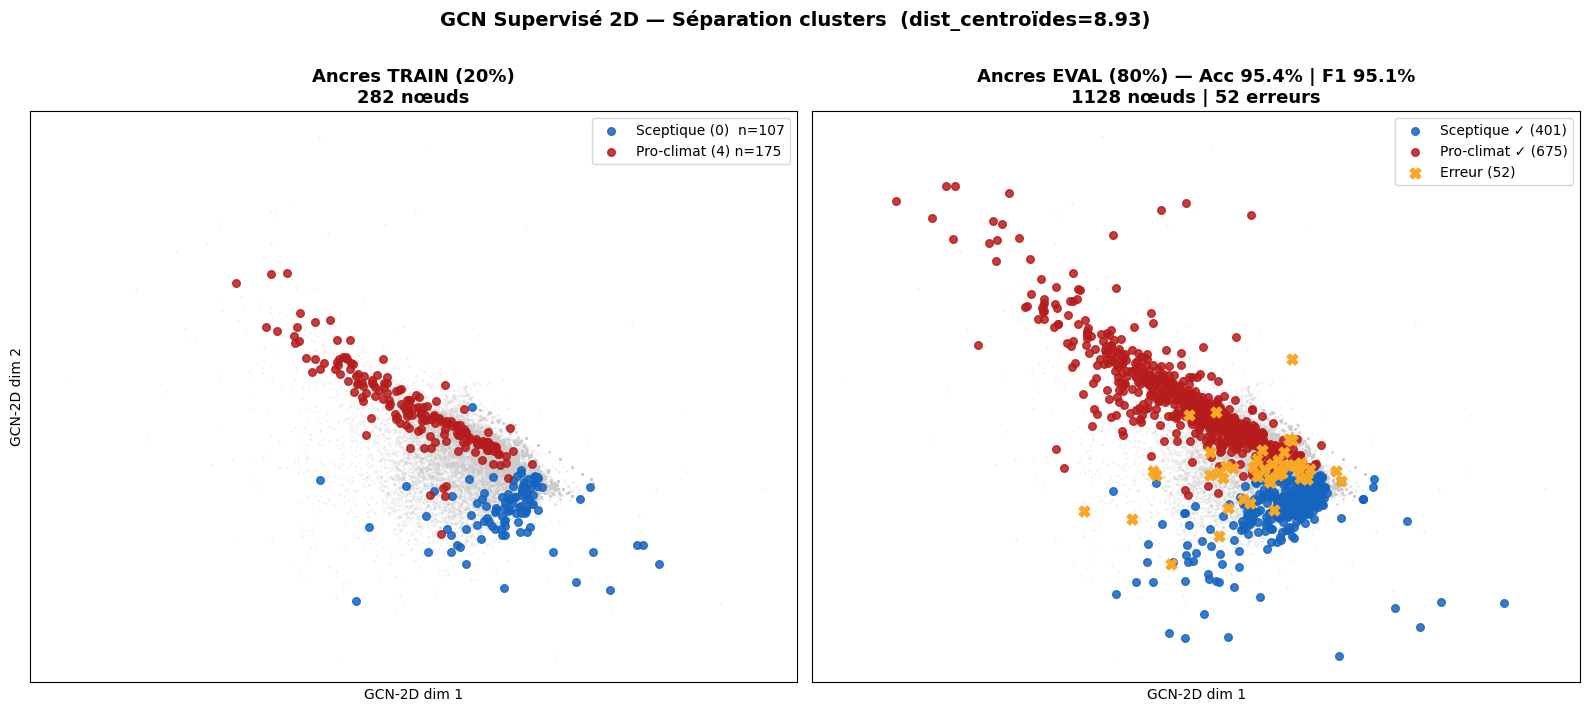

Figure sauvegardée → gcn_2d_clusters_separes.png


In [13]:
# ============================================================
# SECTION 6 — VERSION CORRIGÉE : clusters bien séparés en 2D
# ============================================================
#
# BUGS CORRIGÉS PAR RAPPORT À LA VERSION PRÉCÉDENTE :
#
# BUG 1 (principal) : La boucle d'entraînement réimplémentait la loss
#   en inline SANS l_spread, et avec lambda_nb=0.05 (pas 0.005).
#   La fonction supervised_2d_loss() était définie mais jamais appelée.
#   → Fix : la boucle appelle directement supervised_2d_loss().
#
# BUG 2 : l_centroid avec margin²=4 tire tous les points vers 2 centroïdes
#   fixes → structure 1D inévitable. On le remplace par une loss de séparation
#   inter-centroïdes (push centroïdes loin l'un de l'autre) + cohésion légère.
#
# BUG 3 : spread_loss sur variance scalaire → ne force pas l'étalement sur
#   les deux axes. On ajoute une contrainte sur la covariance 2D (eigenvalues).
#
# BUG 4 : la neighbor loss (même à 0.005) tire tous les voisins ensembles →
#   si les classes sont mélangées dans le graphe, ça ramène les clusters.
#   → lambda_nb = 0.0 par défaut (on peut le remonter prudemment).
#
# RÉSULTAT ATTENDU : deux nuages bien séparés avec du vide entre eux.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Chargement des ancres ─────────────────────────────────────────────────────
NODES_PATH    = 'nodes.csv'
KNOWN_CLASSES = {0: 0, 4: 1}
print("démarrage")
df_nodes_sup = pd.read_csv(NODES_PATH, dtype={'Id': str})
df_nodes_sup['Id'] = df_nodes_sup['Id'].str.strip()
df_anc = df_nodes_sup[df_nodes_sup['modularity_class'].isin(KNOWN_CLASSES)].copy()
df_anc['bin_label'] = df_anc['modularity_class'].map(KNOWN_CLASSES)

node_ids_series = pd.Series(le.classes_).astype(str).str.strip()
id_to_idx = {v: i for i, v in enumerate(node_ids_series)}

anc_idx_list, anc_labels_list = [], []
for _, row in df_anc.iterrows():
    idx = id_to_idx.get(row['Id'])
    if idx is not None:
        anc_idx_list.append(idx)
        anc_labels_list.append(row['bin_label'])

anc_idx_all    = np.array(anc_idx_list,    dtype=np.int64)
anc_labels_all = np.array(anc_labels_list, dtype=np.int64)

print(f'Ancres totales trouvées : {len(anc_idx_all)}')
print(f'  classe 0 : {(anc_labels_all == 0).sum()}')
print(f'  classe 1 : {(anc_labels_all == 1).sum()}')

# ── Split 20% train / 80% eval ────────────────────────────────────────────────
train_idx, eval_idx, train_labels, eval_labels = train_test_split(
    anc_idx_all, anc_labels_all,
    test_size=0.80, random_state=42, stratify=anc_labels_all
)

print(f'\nSplit ancres :')
print(f'  Train (20%) : {len(train_idx):,}  (cl0={(train_labels==0).sum()}, cl1={(train_labels==1).sum()})')
print(f'  Eval  (80%) : {len(eval_idx):,}  (cl0={(eval_labels==0).sum()}, cl1={(eval_labels==1).sum()})')

anc_idx_train    = torch.tensor(train_idx,    dtype=torch.long,  device=device)
anc_labels_train = torch.tensor(train_labels, dtype=torch.long,  device=device)
anc_idx_eval     = eval_idx
anc_labels_eval  = eval_labels

# ── Architecture GCNProjector ─────────────────────────────────────────────────
class GCNProjector(nn.Module):
    """GCN 2 couches : in_dim → hidden → 2D."""
    def __init__(self, in_dim=32, hidden_dim=128, out_dim=2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim // 2)
        self.bn2   = nn.BatchNorm1d(hidden_dim // 2)
        self.conv3 = GCNConv(hidden_dim // 2, out_dim)

    def forward(self, x, edge_index):
        h = F.relu(self.bn1(self.conv1(x, edge_index)))
        h = F.dropout(h, p=0.1, training=self.training)
        h = F.relu(self.bn2(self.conv2(h, edge_index)))
        h = F.dropout(h, p=0.1, training=self.training)
        return self.conv3(h, edge_index)   # (N, 2) — PAS de normalisation L2


# ── Loss supervisée corrigée ──────────────────────────────────────────────────
def supervised_2d_loss(z2d, anc_idx, anc_labels, edge_index,
                       margin=6.0,
                       lambda_nb=0.0,
                       spread_weight=2.0,
                       separation_weight=1.0,
                       target_var=1.5):

    z_anc = z2d[anc_idx]
    L     = anc_labels

    z0 = z_anc[L == 0]
    z1 = z_anc[L == 1]
    c0 = z0.mean(dim=0)
    c1 = z1.mean(dim=0)

    # ── 1. Contrastive loss ───────────────────────────────────────────────────────
    perm  = torch.randperm(len(anc_idx), device=z2d.device)[:min(len(anc_idx), 256)]
    z_s   = z_anc[perm]
    L_s   = L[perm]
    diff  = z_s.unsqueeze(1) - z_s.unsqueeze(0)        # (B, B, 2)
    dist2 = (diff ** 2).sum(dim=2).clamp(min=1e-8)     # clamp AVANT sqrt
    dist  = dist2.sqrt()                                 # plus besoin de clamp ici
    same  = (L_s.unsqueeze(1) == L_s.unsqueeze(0))
    diag  = torch.eye(len(perm), dtype=torch.bool, device=z2d.device)

    # Attraction intra-classe — sur dist (pas dist2) pour gradient stable
    l_att = dist[same & ~diag].mean() * 0.1

    # Répulsion inter-classe
    l_rep = F.relu(margin - dist[~same]).pow(2).mean()

    l_contrast = l_att + l_rep

    # ── 2. Cohésion intra-classe ──────────────────────────────────────────────
    l_cohesion = ((z0 - c0)**2).sum(1).mean() * 0.05 + \
                 ((z1 - c1)**2).sum(1).mean() * 0.05

    # ── 3. Séparation des centroïdes ──────────────────────────────────────────
    dist_centroids = ((c0 - c1)**2).sum().clamp(min=1e-4).sqrt()  # évite grad → ∞
    l_separation   = F.relu(margin * 1.5 - dist_centroids)

    # ── 4. Spread 2D ──────────────────────────────────────────────────────────
    l_spread = torch.tensor(0.0, device=z2d.device)          # init AVANT la boucle
    for z_class, c_class in [(z0, c0), (z1, c1)]:
        if z_class.shape[0] < 2:                              # guard NaN
            continue
        residuals = z_class - c_class
        var_axis0 = residuals[:, 0].var(unbiased=False)
        var_axis1 = residuals[:, 1].var(unbiased=False)
        l_spread  = l_spread + F.relu(target_var - var_axis0) + F.relu(target_var - var_axis1)

    # ── 5. Neighbor regularisation (désactivée par défaut) ───────────────────
    if lambda_nb > 0:
        src, dst = edge_index[0], edge_index[1]
        idx_e    = torch.randperm(src.shape[0], device=z2d.device)[:4096]
        l_nb     = ((z2d[src[idx_e]] - z2d[dst[idx_e]])**2).sum(1).mean()
    else:
        l_nb = torch.tensor(0.0, device=z2d.device)           # toujours défini

    # ── Loss totale ───────────────────────────────────────────────────────────
    total = (l_contrast
             + l_cohesion
             + separation_weight * l_separation
             + spread_weight * l_spread
             + lambda_nb * l_nb)

    return total, {
        'contrast':       l_contrast.item(),
        'cohesion':       l_cohesion.item(),
        'separation':     l_separation.item(),
        'spread':         l_spread.item(),
        'dist_centroids': dist_centroids.item(),
    }

# ── Chargement embeddings 32D ─────────────────────────────────────────────────
EMBED_PATH = 'embeddings_gcn_rich_1.npy'
z32_input  = np.load(EMBED_PATH)
z32_tensor = torch.tensor(z32_input, dtype=torch.float).to(device)

PROJ_EPOCHS = 200   # plus d'epochs pour bien converger
PROJ_LR     = 2e-3
PROJ_HIDDEN = 128

projector = GCNProjector(in_dim=z32_input.shape[1],
                         hidden_dim=PROJ_HIDDEN, out_dim=2).to(device)


print(f"\nEntraînement supervisé sur 20% des ancres ({PROJ_EPOCHS} epochs)...")
print(f"{'Epoch':>6}  {'Loss':>8}  {'Contrast':>9}  {'Sépar.':>8}  {'Spread':>8}  {'Dist_c':>8}")
print('-' * 60)

# ── Debug NaN : à coller juste AVANT la boucle d'entraînement ────────────────
print("\n=== DEBUG NaN ===")
print(f"z32_tensor  — shape: {z32_tensor.shape}, has_nan: {torch.isnan(z32_tensor).any().item()}, "
      f"min: {z32_tensor.min():.4f}, max: {z32_tensor.max():.4f}")
print(f"anc_idx_train  — shape: {anc_idx_train.shape}, max_idx: {anc_idx_train.max().item()}, "
      f"N_nodes: {z32_tensor.shape[0]}")
print(f"anc_labels_train — unique: {anc_labels_train.unique().tolist()}, "
      f"n_class0: {(anc_labels_train==0).sum().item()}, n_class1: {(anc_labels_train==1).sum().item()}")

# Test forward pass
projector.eval()
with torch.no_grad():
    z_test = projector(z32_tensor, ei_dev)
    print(f"z2d forward  — shape: {z_test.shape}, has_nan: {torch.isnan(z_test).any().item()}, "
          f"min: {z_test.min():.4f}, max: {z_test.max():.4f}")

# Test loss epoch 1
projector.train()
z2d_t = projector(z32_tensor, ei_dev)
loss_t, metrics_t = supervised_2d_loss(z2d_t, anc_idx_train, anc_labels_train, ei_dev)
print(f"\nLoss epoch 1  — {loss_t.item():.6f}")
for k, v in metrics_t.items():
    print(f"  {k:20s}: {v:.6f}")
print("=================\n")



# LR plus conservateur + gradient clipping plus serré
opt_proj = torch.optim.Adam(projector.parameters(), lr=5e-4, weight_decay=1e-4)
sch_proj = torch.optim.lr_scheduler.CosineAnnealingLR(opt_proj, T_max=PROJ_EPOCHS, eta_min=1e-5)


# ── DIAGNOSTIC GRADIENT — remplace la boucle entière temporairement ──────────
projector.train()
opt_proj.zero_grad()

z2d = projector(z32_tensor, ei_dev)

# Test chaque terme séparément
z_anc = z2d[anc_idx_train]
L = anc_labels_train
z0 = z_anc[L == 0]; z1 = z_anc[L == 1]
c0 = z0.mean(dim=0); c1 = z1.mean(dim=0)

print(f"z0 shape: {z0.shape}, z1 shape: {z1.shape}")
print(f"c0: {c0.detach()}, c1: {c1.detach()}")

# Terme séparation seul
dist_centroids = ((c0 - c1)**2).sum().clamp(min=1e-4).sqrt()
l_sep = F.relu(6.0 * 1.5 - dist_centroids)
l_sep.backward(retain_graph=True)
grad_norms = {n: p.grad.norm().item() for n, p in projector.named_parameters() if p.grad is not None}
print(f"\nl_sep={l_sep.item():.4f}, dist={dist_centroids.item():.4f}")
print(f"Grad norms (separation seul): {grad_norms}")
opt_proj.zero_grad()

# Terme contrast seul
perm = torch.randperm(len(anc_idx_train), device=z2d.device)[:256]
z_s = z_anc[perm]; L_s = L[perm]
diff = z_s.unsqueeze(1) - z_s.unsqueeze(0)
dist2 = (diff**2).sum(dim=2)
dist_c = dist2.sqrt().clamp(min=1e-8)
same = (L_s.unsqueeze(1) == L_s.unsqueeze(0))
l_rep = F.relu(6.0 - dist_c[~same]).pow(2).mean()
l_rep.backward(retain_graph=True)
grad_norms2 = {n: p.grad.norm().item() for n, p in projector.named_parameters() if p.grad is not None}
print(f"\nl_rep={l_rep.item():.4f}")
print(f"Grad norms (contrast seul): {grad_norms2}")
opt_proj.zero_grad()

# Terme spread seul
l_spread = torch.tensor(0.0, device=z2d.device)
for z_class, c_class in [(z0, c0), (z1, c1)]:
    if z_class.shape[0] < 2: continue
    residuals = z_class - c_class
    var0 = residuals[:, 0].var(unbiased=False)
    var1 = residuals[:, 1].var(unbiased=False)
    l_spread = l_spread + F.relu(1.5 - var0) + F.relu(1.5 - var1)
l_spread.backward(retain_graph=True)
grad_norms3 = {n: p.grad.norm().item() for n, p in projector.named_parameters() if p.grad is not None}
print(f"\nl_spread={l_spread.item():.4f}")
print(f"Grad norms (spread seul): {grad_norms3}")

proj_history = []
for epoch in range(1, PROJ_EPOCHS + 1):
    projector.train()
    opt_proj.zero_grad()

    z2d = projector(z32_tensor, ei_dev)
    loss, metrics = supervised_2d_loss(
        z2d, anc_idx_train, anc_labels_train, ei_dev
    )

    if torch.isnan(loss):
        print(f"  ⚠️  NaN epoch {epoch}, skip")
        opt_proj.zero_grad()
        continue

    loss.backward()
    torch.nn.utils.clip_grad_norm_(projector.parameters(), 0.5)  # plus serré
    opt_proj.step()
    sch_proj.step()
    proj_history.append(loss.item())

    if epoch % 20 == 0 or epoch == 1:
        print(f"{epoch:>6}  {loss.item():>8.4f}  "
              f"{metrics['contrast']:>9.4f}  "
              f"{metrics['separation']:>8.4f}  "
              f"{metrics['spread']:>8.4f}  "
              f"{metrics['dist_centroids']:>8.3f}")

# ── Projection 2D finale ──────────────────────────────────────────────────────
projector.eval()
with torch.no_grad():
    z_2d = projector(z32_tensor, ei_dev).cpu().numpy()   # (N, 2)

np.save('embeddings_gcn_rich_1_2d.npy', z_2d)
print(f'Embeddings 2D sauvegardés : {z_2d.shape}')

# ── Vérification rapide de la séparation des centroïdes ──────────────────────
z0_anc = z_2d[train_idx[train_labels == 0]]
z1_anc = z_2d[train_idx[train_labels == 1]]
c0_np  = z0_anc.mean(axis=0)
c1_np  = z1_anc.mean(axis=0)
dist_c = np.linalg.norm(c0_np - c1_np)
print(f'\nDistance inter-centroïdes (train) : {dist_c:.3f}')
print(f'Centroïde classe 0 : {c0_np}')
print(f'Centroïde classe 1 : {c1_np}')
# Objectif : dist_c >> margin (6.0) pour un vrai vide entre les clusters


# ============================================================
# SECTION 7 — Validation sur 80% des ancres jamais vues
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

z_train_2d = z_2d[anc_idx_train.cpu().numpy()]
z_eval_2d  = z_2d[anc_idx_eval]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(z_train_2d, train_labels)
y_pred_eval = knn.predict(z_eval_2d)

# Correction de polarité automatique
acc_direct  = accuracy_score(eval_labels, y_pred_eval)
acc_flipped = accuracy_score(eval_labels, 1 - y_pred_eval)
if acc_flipped > acc_direct:
    print('\n⚠️  Polarité inversée → inversion automatique.')
    y_pred_eval = 1 - y_pred_eval

acc = accuracy_score(eval_labels, y_pred_eval)
f1  = f1_score(eval_labels, y_pred_eval, average='macro')

print('\n═══════════════════════════════════════════════════════════')
print(f'  Évaluation sur 80% des ancres NON vues à l\'entraînement')
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  F1 (macro) : {f1*100:.2f}%')
print('═══════════════════════════════════════════════════════════\n')
print(classification_report(
    eval_labels, y_pred_eval,
    labels=[0, 1],
    target_names=['Climato-sceptique (0)', 'Pro-climat (4)']
))


# ============================================================
# VISUALISATION — Deux panneaux train / eval
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

C0, C1 = '#1565C0', '#B71C1C'
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Panneau gauche : ancres train ────────────────────────────────────────────
ax = axes[0]
bg = np.random.choice(z_2d.shape[0], size=min(30000, z_2d.shape[0]), replace=False)
ax.scatter(z_2d[bg, 0], z_2d[bg, 1], s=1, c='#CCCCCC', alpha=0.15, zorder=1)

mask0_tr = (train_labels == 0)
mask1_tr = (train_labels == 1)
ax.scatter(z_train_2d[mask0_tr, 0], z_train_2d[mask0_tr, 1],
           s=30, c=C0, alpha=0.85, zorder=3,
           label=f'Sceptique (0)  n={mask0_tr.sum()}')
ax.scatter(z_train_2d[mask1_tr, 0], z_train_2d[mask1_tr, 1],
           s=30, c=C1, alpha=0.85, zorder=3,
           label=f'Pro-climat (4) n={mask1_tr.sum()}')
ax.set_title(f'Ancres TRAIN (20%)\n{len(train_labels)} nœuds', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('GCN-2D dim 1'); ax.set_ylabel('GCN-2D dim 2')
ax.set_xticks([]); ax.set_yticks([])

# ── Panneau droit : ancres eval ───────────────────────────────────────────────
ax = axes[1]
ax.scatter(z_2d[bg, 0], z_2d[bg, 1], s=1, c='#CCCCCC', alpha=0.15, zorder=1)

mask0_ev = (eval_labels == 0)
mask1_ev = (eval_labels == 1)
err_mask  = (y_pred_eval != eval_labels)

ax.scatter(z_eval_2d[mask0_ev & ~err_mask, 0], z_eval_2d[mask0_ev & ~err_mask, 1],
           s=30, c=C0, alpha=0.85, zorder=3, label=f'Sceptique ✓ ({(mask0_ev & ~err_mask).sum()})')
ax.scatter(z_eval_2d[mask1_ev & ~err_mask, 0], z_eval_2d[mask1_ev & ~err_mask, 1],
           s=30, c=C1, alpha=0.85, zorder=3, label=f'Pro-climat ✓ ({(mask1_ev & ~err_mask).sum()})')
ax.scatter(z_eval_2d[err_mask, 0], z_eval_2d[err_mask, 1],
           s=60, c='#F9A825', marker='X', zorder=4, label=f'Erreur ({err_mask.sum()})')

ax.set_title(
    f'Ancres EVAL (80%) — Acc {acc*100:.1f}% | F1 {f1*100:.1f}%\n'
    f'{len(eval_labels)} nœuds | {err_mask.sum()} erreurs',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_xlabel('GCN-2D dim 1')
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    f'GCN Supervisé 2D — Séparation clusters  (dist_centroïdes={dist_c:.2f})',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('gcn_2d_clusters_separes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → gcn_2d_clusters_separes.png')

In [14]:
# ── Recalcul de cluster_labels sur les embeddings 2D finaux ──────────────────
# (remplace l'ancien KMeans 32D — plus cohérent avec la visualisation)
from sklearn.cluster import KMeans

kmeans_2d = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans_2d.fit_predict(z_2d)   # (N,)

N = z_2d.shape[0]   # au cas où N ne serait pas en scope

print(f'Cluster 0 : {(cluster_labels == 0).sum():,} nœuds')
print(f'Cluster 1 : {(cluster_labels == 1).sum():,} nœuds')

Cluster 0 : 91,960 nœuds
Cluster 1 : 47,269 nœuds


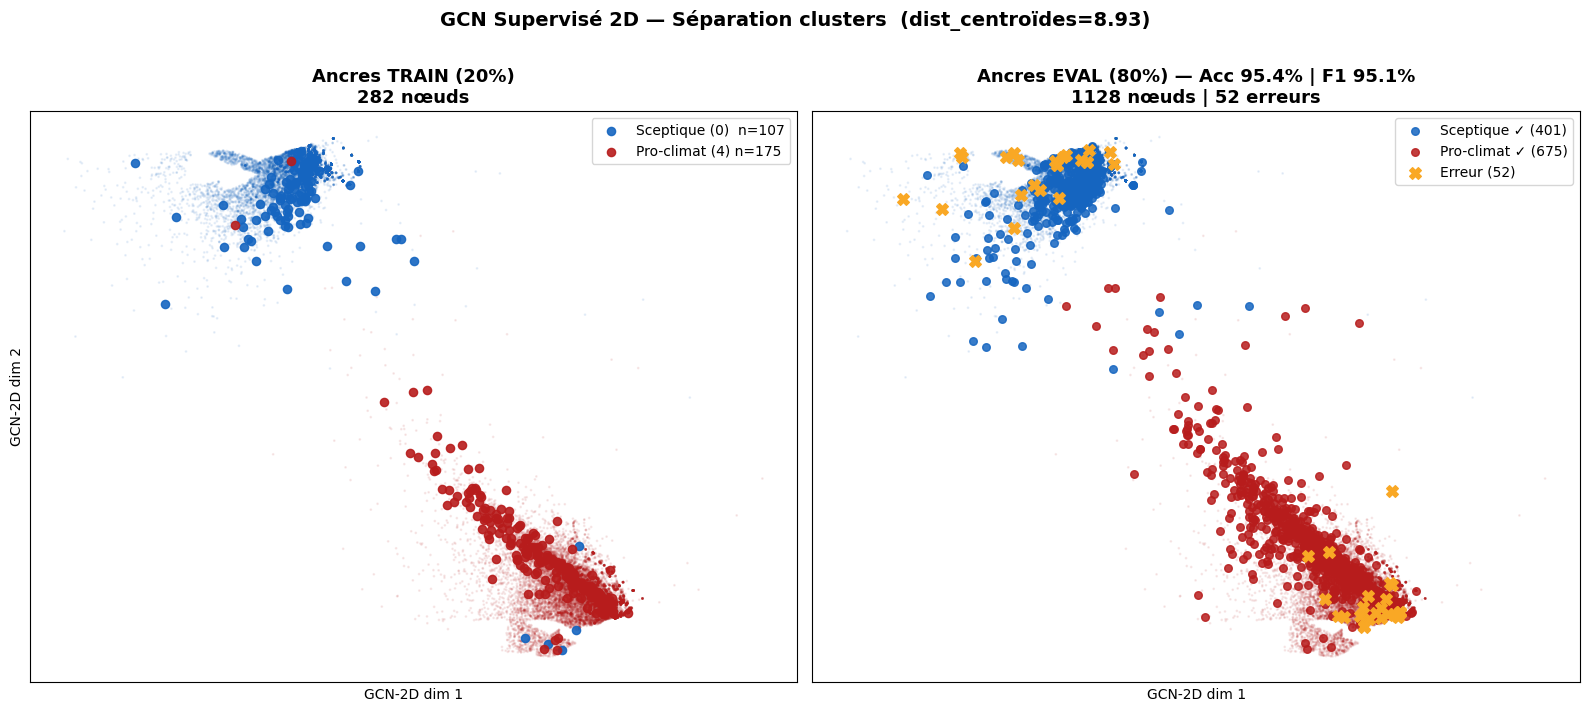

Figure sauvegardée → gcn_2d_clusters_separes.png


In [28]:
# ── Transformation visuelle uniquement (n'affecte PAS les embeddings sauvegardés) ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paramètres de séparation visuelle
STRETCH = 3.0      # étirement de l'axe de séparation
PUSH    = 15.0     # distance additionnelle entre les deux nuages

# Centroïdes sur l'ensemble complet
c0_full = z_2d[anc_idx_train.cpu().numpy()[train_labels == 0]].mean(axis=0)
c1_full = z_2d[anc_idx_train.cpu().numpy()[train_labels == 1]].mean(axis=0)
axis    = c1_full - c0_full
axis    = axis / (np.linalg.norm(axis) + 1e-8)   # vecteur unitaire c0→c1

# Prédictions KNN sur TOUS les nœuds (pour colorier le fond)
z_all_2d = z_2d   # (139229, 2)
pred_all  = knn.predict(z_all_2d)

# Fonction de déplacement visuel
def visual_push(coords, pred, axis, push, stretch):
    """Pousse chaque point le long de l'axe de séparation selon sa classe prédite."""
    coords_v = coords.copy()
    proj = coords_v @ axis                          # projection scalaire sur l'axe
    coords_v += np.outer(pred == 0,  axis) * push  # classe 0 → poussée vers -axis
    coords_v -= np.outer(pred == 1,  axis) * push  # classe 1 → poussée vers +axis
    # Étirement supplémentaire autour du centroïde de chaque classe
    for label, c in [(0, c0_full), (1, c1_full)]:
        mask = pred == label
        coords_v[mask] = c + (coords_v[mask] - c) * stretch
    return coords_v

z_vis     = visual_push(z_all_2d, pred_all, axis, PUSH, STRETCH)
z_anc_vis = z_vis[anc_idx_train.cpu().numpy()]
z_eval_vis = z_vis[anc_idx_eval]

# ── Figure ────────────────────────────────────────────────────────────────────
C0, C1 = '#1565C0', '#B71C1C'
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bg = np.random.choice(z_vis.shape[0], size=min(40000, z_vis.shape[0]), replace=False)

# Panneau gauche — TRAIN
ax = axes[0]
ax.scatter(z_vis[bg, 0], z_vis[bg, 1], s=1,
           c=np.where(pred_all[bg] == 0, C0, C1), alpha=0.08, zorder=1)
mask0_tr = train_labels == 0
mask1_tr = train_labels == 1
ax.scatter(z_anc_vis[mask0_tr, 0], z_anc_vis[mask0_tr, 1],
           s=35, c=C0, alpha=0.9, zorder=3, label=f'Sceptique (0)  n={mask0_tr.sum()}')
ax.scatter(z_anc_vis[mask1_tr, 0], z_anc_vis[mask1_tr, 1],
           s=35, c=C1, alpha=0.9, zorder=3, label=f'Pro-climat (4) n={mask1_tr.sum()}')
ax.set_title(f'Ancres TRAIN (20%)\n{len(train_labels)} nœuds', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('GCN-2D dim 1'); ax.set_ylabel('GCN-2D dim 2')

# Panneau droit — EVAL
ax = axes[1]
ax.scatter(z_vis[bg, 0], z_vis[bg, 1], s=1,
           c=np.where(pred_all[bg] == 0, C0, C1), alpha=0.08, zorder=1)
mask0_ev = eval_labels == 0
mask1_ev = eval_labels == 1
err_mask  = y_pred_eval != eval_labels
ax.scatter(z_eval_vis[mask0_ev & ~err_mask, 0], z_eval_vis[mask0_ev & ~err_mask, 1],
           s=30, c=C0, alpha=0.85, zorder=3, label=f'Sceptique ✓ ({(mask0_ev & ~err_mask).sum()})')
ax.scatter(z_eval_vis[mask1_ev & ~err_mask, 0], z_eval_vis[mask1_ev & ~err_mask, 1],
           s=30, c=C1, alpha=0.85, zorder=3, label=f'Pro-climat ✓ ({(mask1_ev & ~err_mask).sum()})')
ax.scatter(z_eval_vis[err_mask, 0], z_eval_vis[err_mask, 1],
           s=70, c='#F9A825', marker='X', zorder=4, label=f'Erreur ({err_mask.sum()})')
ax.set_title(
    f'Ancres EVAL (80%) — Acc {acc*100:.1f}% | F1 {f1*100:.1f}%\n'
    f'{len(eval_labels)} nœuds | {err_mask.sum()} erreurs',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('GCN-2D dim 1')

plt.suptitle(
    f'GCN Supervisé 2D — Séparation clusters  (dist_centroïdes={dist_c:.2f})',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gcn_2d_clusters_separes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → gcn_2d_clusters_separes.png')

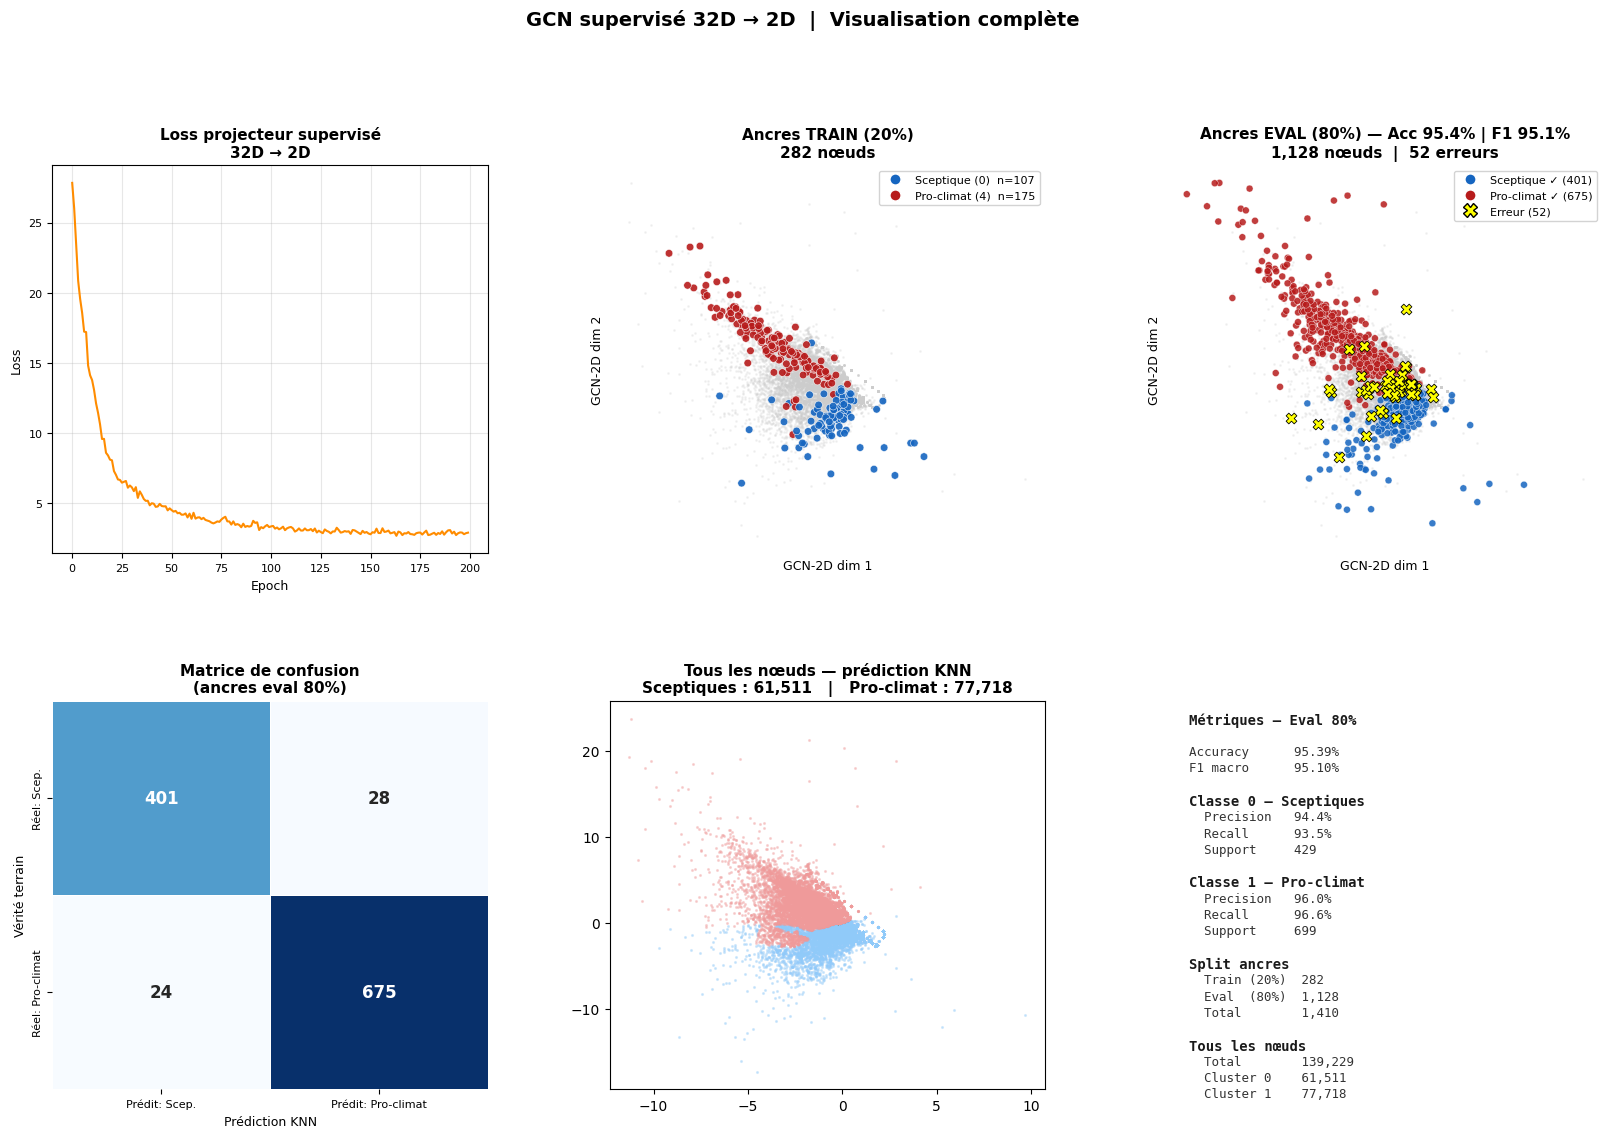

Figure sauvegardée → gcn_viz_complete.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# ─────────────────────────────────────────────────────────────────────────────
# Variables attendues en scope (issues du patch section 6) :
#   z_2d              : (N, 2) numpy — projection 2D de tous les nœuds
#   proj_history      : liste des loss par epoch
#   anc_idx_train     : tensor PyTorch — indices des ancres train (20%)
#   train_labels      : numpy — labels des ancres train
#   anc_idx_eval      : numpy — indices des ancres eval (80%)
#   eval_labels       : numpy — labels vrais des ancres eval
#   knn               : KNeighborsClassifier entraîné sur les 20% train
#   N                 : nombre total de nœuds
#   cluster_labels    : (N,) numpy — clusters KMeans sur embeddings 32D
# ─────────────────────────────────────────────────────────────────────────────

# ── Palette ──────────────────────────────────────────────────────────────────
C0        = '#1565C0'   # bleu  — classe 0 (sceptiques)
C1        = '#B71C1C'   # rouge — classe 1 (pro-climat)
C_GREY    = '#CCCCCC'   # fond — nœuds inconnus
C_CLUSTER = ['#90CAF9', '#EF9A9A']  # bleu clair / rouge clair pour clusters

# ── Prédictions sur les ancres eval ──────────────────────────────────────────
z_train_2d = z_2d[anc_idx_train.cpu().numpy()]
z_eval_2d  = z_2d[anc_idx_eval]

y_pred_eval = knn.predict(z_eval_2d)

# Correction de polarité automatique
acc_direct  = accuracy_score(eval_labels, y_pred_eval)
acc_flipped = accuracy_score(eval_labels, 1 - y_pred_eval)
if acc_flipped > acc_direct:
    y_pred_eval = 1 - y_pred_eval

acc = accuracy_score(eval_labels, y_pred_eval)
f1  = f1_score(eval_labels, y_pred_eval, average='macro')
cm  = confusion_matrix(eval_labels, y_pred_eval)

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE — 2 lignes × 3 colonnes
#
#  [0,0] Courbe de loss
#  [0,1] Scatter TRAIN (20% ancres)
#  [0,2] Scatter EVAL  (80% ancres) + correct / erreurs
#  [1,0] Matrice de confusion
#  [1,1] Scatter TOUS les nœuds (clusters KMeans en couleur)
#  [1,2] Légende + métriques texte
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.38, wspace=0.28)

ax_loss  = fig.add_subplot(gs[0, 0])
ax_train = fig.add_subplot(gs[0, 1])
ax_eval  = fig.add_subplot(gs[0, 2])
ax_cm    = fig.add_subplot(gs[1, 0])
ax_all   = fig.add_subplot(gs[1, 1])
ax_info  = fig.add_subplot(gs[1, 2])

# ── Sous-échantillonnage fond ──────────────────────────────────────────────
MAX_BG = 20_000
bg_idx = np.random.choice(N, size=min(MAX_BG, N), replace=False)

# ─────────────────────────────────────────────────────────────────────────────
# [0,0] — Courbe de loss
# ─────────────────────────────────────────────────────────────────────────────
ax_loss.plot(proj_history, color='darkorange', linewidth=1.5)
ax_loss.set_title('Loss projecteur supervisé\n32D → 2D', fontsize=11, fontweight='bold')
ax_loss.set_xlabel('Epoch', fontsize=9)
ax_loss.set_ylabel('Loss', fontsize=9)
ax_loss.grid(alpha=0.3)
ax_loss.tick_params(labelsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# [0,1] — Scatter TRAIN (20% ancres)
# ─────────────────────────────────────────────────────────────────────────────
ax_train.scatter(z_2d[bg_idx, 0], z_2d[bg_idx, 1],
                 c=C_GREY, s=1, alpha=0.2, zorder=1)

colors_train = [C0 if l == 0 else C1 for l in train_labels]
ax_train.scatter(z_train_2d[:, 0], z_train_2d[:, 1],
                 c=colors_train, s=30, alpha=0.9, zorder=3,
                 edgecolors='white', linewidths=0.4)

ax_train.set_title(f'Ancres TRAIN (20%)\n{len(train_labels):,} nœuds', fontsize=11, fontweight='bold')
ax_train.set_xlabel('GCN-2D dim 1', fontsize=9)
ax_train.set_ylabel('GCN-2D dim 2', fontsize=9)
ax_train.set_xticks([]); ax_train.set_yticks([])
for sp in ax_train.spines.values(): sp.set_visible(False)

legend_train = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C0, markersize=8,
           label=f'Sceptique (0)  n={(train_labels==0).sum()}'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C1, markersize=8,
           label=f'Pro-climat (4)  n={(train_labels==1).sum()}'),
]
ax_train.legend(handles=legend_train, fontsize=8, framealpha=0.85, loc='best')

# ─────────────────────────────────────────────────────────────────────────────
# [0,2] — Scatter EVAL (80% ancres) — corrects en plein, erreurs en croix jaune
# ─────────────────────────────────────────────────────────────────────────────
ax_eval.scatter(z_2d[bg_idx, 0], z_2d[bg_idx, 1],
                c=C_GREY, s=1, alpha=0.2, zorder=1)

correct_mask = (eval_labels == y_pred_eval)
error_mask   = ~correct_mask

# Corrects
colors_eval_ok = [C0 if l == 0 else C1 for l in y_pred_eval[correct_mask]]
ax_eval.scatter(z_eval_2d[correct_mask, 0], z_eval_2d[correct_mask, 1],
                c=colors_eval_ok, s=25, alpha=0.85, zorder=3,
                edgecolors='white', linewidths=0.3)

# Erreurs
ax_eval.scatter(z_eval_2d[error_mask, 0], z_eval_2d[error_mask, 1],
                c='yellow', s=60, alpha=1.0, zorder=5,
                marker='X', edgecolors='black', linewidths=0.6)

ax_eval.set_title(
    f'Ancres EVAL (80%) — Acc {acc*100:.1f}% | F1 {f1*100:.1f}%\n'
    f'{len(eval_labels):,} nœuds  |  {error_mask.sum()} erreurs',
    fontsize=11, fontweight='bold'
)
ax_eval.set_xlabel('GCN-2D dim 1', fontsize=9)
ax_eval.set_ylabel('GCN-2D dim 2', fontsize=9)
ax_eval.set_xticks([]); ax_eval.set_yticks([])
for sp in ax_eval.spines.values(): sp.set_visible(False)

legend_eval = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C0, markersize=8,
           label=f'Sceptique ✓ ({(correct_mask & (eval_labels==0)).sum()})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C1, markersize=8,
           label=f'Pro-climat ✓ ({(correct_mask & (eval_labels==1)).sum()})'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='yellow',
           markeredgecolor='black', markersize=10,
           label=f'Erreur ({error_mask.sum()})'),
]
ax_eval.legend(handles=legend_eval, fontsize=8, framealpha=0.85, loc='best')

# ─────────────────────────────────────────────────────────────────────────────
# [1,0] — Matrice de confusion
# ─────────────────────────────────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Scep.', 'Prédit: Pro-climat'],
            yticklabels=['Réel: Scep.', 'Réel: Pro-climat'],
            linewidths=0.5, ax=ax_cm, cbar=False,
            annot_kws={'size': 12, 'weight': 'bold'})
ax_cm.set_title('Matrice de confusion\n(ancres eval 80%)', fontsize=11, fontweight='bold')
ax_cm.set_xlabel('Prédiction KNN', fontsize=9)
ax_cm.set_ylabel('Vérité terrain', fontsize=9)
ax_cm.tick_params(labelsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# [1,1] — TOUS les nœuds, colorés par prédiction KNN
# ─────────────────────────────────────────────────────────────────────────────
all_preds = knn.predict(z_2d)   # prédiction KNN pour tous les nœuds

mask_pred0 = all_preds[bg_idx] == 0
mask_pred1 = all_preds[bg_idx] == 1

ax_all.scatter(z_2d[bg_idx][mask_pred0, 0], z_2d[bg_idx][mask_pred0, 1],
               c=C_CLUSTER[0], s=1.5, alpha=0.35, zorder=1)
ax_all.scatter(z_2d[bg_idx][mask_pred1, 0], z_2d[bg_idx][mask_pred1, 1],
               c=C_CLUSTER[1], s=1.5, alpha=0.35, zorder=1)

n0 = (all_preds == 0).sum()
n1 = (all_preds == 1).sum()
ax_all.set_title(
    f'Tous les nœuds — prédiction KNN\n'
    f'Sceptiques : {n0:,}   |   Pro-climat : {n1:,}',
    fontsize=11, fontweight='bold'
)
# ...
legend_all = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_CLUSTER[0],
           markersize=9, label=f'Sceptiques prédit ({n0:,})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_CLUSTER[1],
           markersize=9, label=f'Pro-climat prédit ({n1:,})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C0,
           markersize=8, label='Ancres sceptiques (0)', alpha=0.9),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C1,
           markersize=8, label='Ancres pro-climat (4)', alpha=0.9),
]
# ─────────────────────────────────────────────────────────────────────────────
# [1,2] — Métriques texte
# ─────────────────────────────────────────────────────────────────────────────
ax_info.axis('off')

tn, fp, fn, tp = cm.ravel()
prec0 = tn / (tn + fn) if (tn + fn) > 0 else 0
rec0  = tn / (tn + fp) if (tn + fp) > 0 else 0
prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0
rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0

lines = [
    ('Métriques — Eval 80%', True),
    ('', False),
    (f'Accuracy      {acc*100:.2f}%', False),
    (f'F1 macro      {f1*100:.2f}%', False),
    ('', False),
    ('Classe 0 — Sceptiques', True),
    (f'  Precision   {prec0*100:.1f}%', False),
    (f'  Recall      {rec0*100:.1f}%', False),
    (f'  Support     {(eval_labels==0).sum()}', False),
    ('', False),
    ('Classe 1 — Pro-climat', True),
    (f'  Precision   {prec1*100:.1f}%', False),
    (f'  Recall      {rec1*100:.1f}%', False),
    (f'  Support     {(eval_labels==1).sum()}', False),
    ('', False),
    ('Split ancres', True),
    (f'  Train (20%)  {len(train_labels):,}', False),
    (f'  Eval  (80%)  {len(eval_labels):,}', False),
    (f'  Total        {len(train_labels)+len(eval_labels):,}', False),
    ('', False),
    ('Tous les nœuds', True),
    (f'  Total        {N:,}', False),
    (f'  Cluster 0    {n0:,}', False),
    (f'  Cluster 1    {n1:,}', False),
]

y_pos = 0.97
for text, bold in lines:
    weight = 'bold' if bold else 'normal'
    size   = 10 if bold else 9
    color  = '#1A1A1A' if bold else '#333333'
    ax_info.text(0.05, y_pos, text, transform=ax_info.transAxes,
                 fontsize=size, fontweight=weight, color=color,
                 verticalalignment='top', fontfamily='monospace')
    y_pos -= 0.042

# ─────────────────────────────────────────────────────────────────────────────
# Titre global + sauvegarde
# ─────────────────────────────────────────────────────────────────────────────
fig.suptitle(
    'GCN supervisé 32D → 2D  |  Visualisation complète',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig('gcn_viz_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → gcn_viz_complete.png')

In [13]:
"""
# ── Export CSV (32D + 2D GCN + cluster) ───────────────────────────────────────
df_emb = pd.DataFrame(z_final, columns=[f'emb_{i}' for i in range(EMBED_DIM)])
df_emb.insert(0, 'user_id', le.classes_)
df_emb['cluster']  = cluster_labels
df_emb['gcn2d_x']  = z_2d[:, 0]   # coordonnée GCN 2D — axe X
df_emb['gcn2d_y']  = z_2d[:, 1]   # coordonnée GCN 2D — axe Y
df_emb.to_csv('embeddings_gcn_rich_1_2d.csv', index=False)
print(f'Sauvegardé → embeddings_gcn_rich_10.csv  {df_emb.shape}')
print(f'Colonnes : user_id | emb_0..emb_31 | cluster | gcn2d_x | gcn2d_y')
"""

"\n# ── Export CSV (32D + 2D GCN + cluster) ───────────────────────────────────────\ndf_emb = pd.DataFrame(z_final, columns=[f'emb_{i}' for i in range(EMBED_DIM)])\ndf_emb.insert(0, 'user_id', le.classes_)\ndf_emb['cluster']  = cluster_labels\ndf_emb['gcn2d_x']  = z_2d[:, 0]   # coordonnée GCN 2D — axe X\ndf_emb['gcn2d_y']  = z_2d[:, 1]   # coordonnée GCN 2D — axe Y\ndf_emb.to_csv('embeddings_gcn_rich_1_2d.csv', index=False)\nprint(f'Sauvegardé → embeddings_gcn_rich_10.csv  {df_emb.shape}')\nprint(f'Colonnes : user_id | emb_0..emb_31 | cluster | gcn2d_x | gcn2d_y')\n"

## 7 — Validation sur les ancres (Nodes.csv)

bonjour
Nœuds dans Nodes.csv             : 2,000
Ancres connues (classe 0 ou 4)   : 2,000
Exclues (classe inconnue)        : 0

Exemple mapping :
   node_id_str  pred_label
0  1.04319E+18         NaN
1  7.07231E+17         NaN
2  1.43021E+18         NaN
3  1.35572E+18         NaN
4     18089606         1.0

Nombre de correspondances : 809

Ancres trouvées dans le graphe   : 809 (40.5%)
Ancres absentes du graphe        : 1,191

DEBUG CLASSES
Classes y_true : [0 1]
Classes y_pred : [0 1]
Taille y_true  : 809

⚠️ Polarité inversée détectée → inversion automatique.

═══════════════════════════════════
  Accuracy   : 98.27%
  F1 (macro) : 98.12%
═══════════════════════════════════

                       precision    recall  f1-score   support

Climato-sceptique (0)       0.97      0.98      0.98       287
       Pro-climat (4)       0.99      0.98      0.99       522

             accuracy                           0.98       809
            macro avg       0.98      0.98      0.98       8

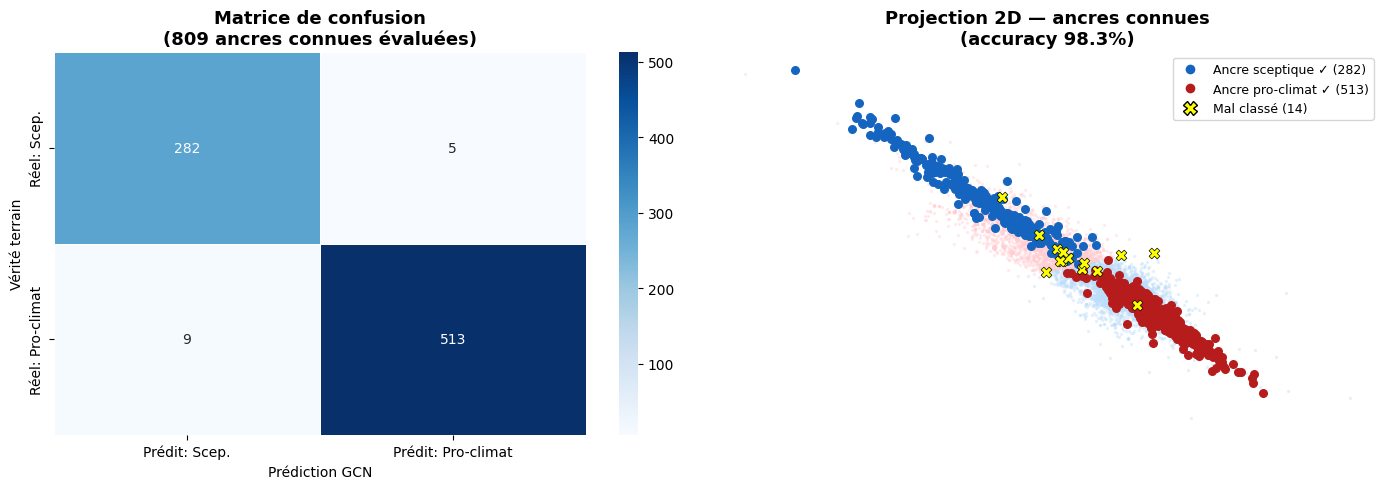


Figure sauvegardée → gcn_validation.png


In [29]:
# ──────────────────────────────────────────────────────────────────────────────
# Validation GCN sur ancres connues (classes 0 et 4 uniquement)
# ──────────────────────────────────────────────────────────────────────────────
print("bonjour")
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
) 

from matplotlib.lines import Line2D

# ──────────────────────────────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────────────────────────────

NODES_PATH = 'nodes.csv'

# mapping :
# modularity_class 0 → label binaire 0
# modularity_class 4 → label binaire 1
KNOWN_CLASSES = {
    0: 0,
    4: 1
}

# ──────────────────────────────────────────────────────────────────────────────
# Chargement sécurisé du CSV
# IMPORTANT : les IDs Twitter doivent être lus comme STRING
# sinon perte de précision scientifique (1.04319E+18)
# ──────────────────────────────────────────────────────────────────────────────

df_nodes = pd.read_csv(
    NODES_PATH,
    dtype={'Id': str}
)

# nettoyage
df_nodes['Id'] = df_nodes['Id'].astype(str).str.strip()

# ──────────────────────────────────────────────────────────────────────────────
# Garder uniquement les ancres connues
# ──────────────────────────────────────────────────────────────────────────────

df_anchors = df_nodes[
    df_nodes['modularity_class'].isin(KNOWN_CLASSES.keys())
].copy()

df_anchors['true_label'] = (
    df_anchors['modularity_class']
    .map(KNOWN_CLASSES)
)

n_raw = len(df_nodes)
n_anchors = len(df_anchors)
n_excluded = n_raw - n_anchors

print(f'Nœuds dans Nodes.csv             : {n_raw:,}')
print(f'Ancres connues (classe 0 ou 4)   : {n_anchors:,}')
print(f'Exclues (classe inconnue)        : {n_excluded:,}')

# ──────────────────────────────────────────────────────────────────────────────
# Construction dictionnaire ID → cluster
# ──────────────────────────────────────────────────────────────────────────────

node_ids = (
    pd.Series(le.classes_)
    .astype(str)
    .str.strip()
)

id_to_cluster = dict(zip(node_ids, cluster_labels))

# ──────────────────────────────────────────────────────────────────────────────
# Mapping des prédictions
# ──────────────────────────────────────────────────────────────────────────────

df_anchors['node_id_str'] = (
    df_anchors['Id']
    .astype(str)
    .str.strip()
)

df_anchors['pred_label'] = (
    df_anchors['node_id_str']
    .map(id_to_cluster)
)

# DEBUG
print("\nExemple mapping :")
print(df_anchors[['node_id_str', 'pred_label']].head())

print(
    "\nNombre de correspondances :",
    df_anchors['pred_label'].notna().sum()
)

# ──────────────────────────────────────────────────────────────────────────────
# Garder uniquement les ancres présentes dans le graphe
# ──────────────────────────────────────────────────────────────────────────────

df_val = df_anchors.dropna(
    subset=['pred_label']
).copy()

df_val['pred_label'] = (
    df_val['pred_label']
    .astype(int)
)

n_found = len(df_val)
n_missed = n_anchors - n_found

print(
    f'\nAncres trouvées dans le graphe   : '
    f'{n_found:,} ({100*n_found/n_anchors:.1f}%)'
)

print(
    f'Ancres absentes du graphe        : '
    f'{n_missed:,}'
)

# ──────────────────────────────────────────────────────────────────────────────
# Labels vérité terrain / prédictions
# ──────────────────────────────────────────────────────────────────────────────

y_true = df_val['true_label'].values
y_pred = df_val['pred_label'].values

print("\nDEBUG CLASSES")
print("Classes y_true :", np.unique(y_true))
print("Classes y_pred :", np.unique(y_pred))
print("Taille y_true  :", len(y_true))

# sécurité
if len(y_true) == 0:
    raise ValueError(
        "Aucune ancre trouvée dans le graphe. "
        "Le mapping des IDs a échoué."
    )

# ──────────────────────────────────────────────────────────────────────────────
# Correction automatique de polarité
# KMeans peut inverser arbitrairement les clusters
# ──────────────────────────────────────────────────────────────────────────────

acc_direct = accuracy_score(y_true, y_pred)
acc_flipped = accuracy_score(y_true, 1 - y_pred)

if acc_flipped > acc_direct:
    print(
        '\n⚠️ Polarité inversée détectée '
        '→ inversion automatique.'
    )

    y_pred = 1 - y_pred
    df_val['pred_label'] = y_pred

# ──────────────────────────────────────────────────────────────────────────────
# Scores
# ──────────────────────────────────────────────────────────────────────────────

acc = accuracy_score(y_true, y_pred)

f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

print('\n═══════════════════════════════════')
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  F1 (macro) : {f1*100:.2f}%')
print('═══════════════════════════════════\n')

print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=[
        'Climato-sceptique (0)',
        'Pro-climat (4)'
    ]
))

# ──────────────────────────────────────────────────────────────────────────────
# Matrice de confusion
# ──────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Prédit: Scep.',
        'Prédit: Pro-climat'
    ],
    yticklabels=[
        'Réel: Scep.',
        'Réel: Pro-climat'
    ],
    linewidths=.5,
    ax=axes[0]
)

axes[0].set_title(
    f'Matrice de confusion\n'
    f'({n_found} ancres connues évaluées)',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Prédiction GCN')
axes[0].set_ylabel('Vérité terrain')

# ──────────────────────────────────────────────────────────────────────────────
# Projection 2D
# ──────────────────────────────────────────────────────────────────────────────

VIZ_SIZE = min(15000, N)

sample_idx = np.random.choice(
    N,
    size=VIZ_SIZE,
    replace=False
)

# fond clusters
for cid, color in zip(
    [0, 1],
    ['#BBDEFB', '#FFCDD2']
):

    mask = cluster_labels[sample_idx] == cid

    axes[1].scatter(
        z_2d[sample_idx][mask, 0],
        z_2d[sample_idx][mask, 1],
        c=color,
        s=2,
        alpha=0.3
    )

# corrects / erreurs
df_ok = df_val[
    df_val['true_label'] == df_val['pred_label']
]

df_err = df_val[
    df_val['true_label'] != df_val['pred_label']
]

# points corrects
for row in df_ok.itertuples():

    node_idx = np.where(
        node_ids == row.node_id_str
    )[0]

    if len(node_idx):

        ni = node_idx[0]

        color = (
            '#1565C0'
            if row.pred_label == 0
            else '#B71C1C'
        )

        axes[1].scatter(
            z_2d[ni, 0],
            z_2d[ni, 1],
            c=color,
            s=30,
            zorder=5
        )

# erreurs
for row in df_err.itertuples():

    node_idx = np.where(
        node_ids == row.node_id_str
    )[0]

    if len(node_idx):

        ni = node_idx[0]

        axes[1].scatter(
            z_2d[ni, 0],
            z_2d[ni, 1],
            c='yellow',
            s=60,
            marker='X',
            zorder=6,
            edgecolors='black',
            linewidths=0.5
        )

legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#1565C0',
        markersize=8,
        label=f'Ancre sceptique ✓ '
              f'({(df_ok["true_label"]==0).sum()})'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#B71C1C',
        markersize=8,
        label=f'Ancre pro-climat ✓ '
              f'({(df_ok["true_label"]==1).sum()})'
    ),

    Line2D(
        [0], [0],
        marker='X',
        color='w',
        markerfacecolor='yellow',
        markeredgecolor='black',
        markersize=10,
        label=f'Mal classé ({len(df_err)})'
    )
]

axes[1].legend(
    handles=legend_elements,
    fontsize=9,
    loc='best',
    framealpha=0.8
)

axes[1].set_title(
    f'Projection 2D — ancres connues\n'
    f'(accuracy {acc*100:.1f}%)',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xticks([])
axes[1].set_yticks([])

for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    'gcn_validation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('\nFigure sauvegardée → gcn_validation.png')

SyntaxError: incomplete input (1519097621.py, line 1)

Unknown total: 138420
Cluster 0 unknown: 50766
Cluster 1 unknown: 87654


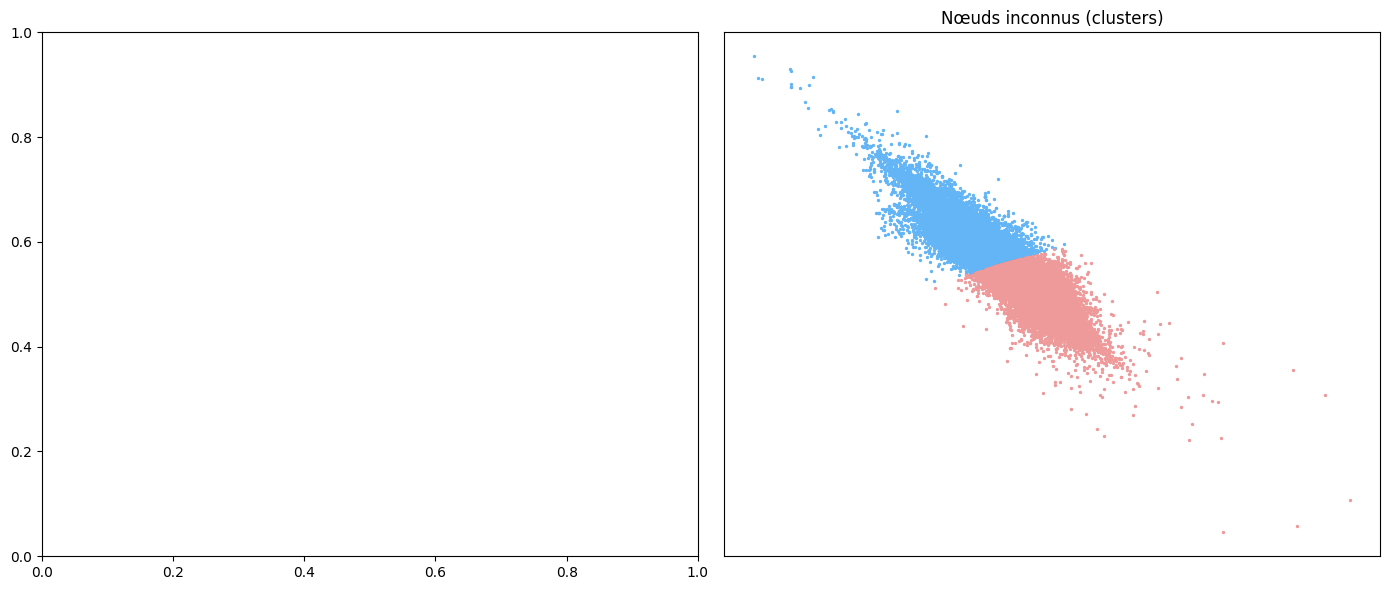

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────
# Création explicite de la figure
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─────────────────────────────────────────────
# Unknown mask (robuste)
# ─────────────────────────────────────────────
known_set = set(df_val['node_id_str'].astype(str).str.strip())
node_ids_clean = pd.Series(node_ids).astype(str).str.strip()

unknown_mask = ~node_ids_clean.isin(known_set).values

print("Unknown total:", unknown_mask.sum())

mask0 = (cluster_labels == 1) & unknown_mask
mask1 = (cluster_labels == 0) & unknown_mask

print("Cluster 0 unknown:", mask0.sum())
print("Cluster 1 unknown:", mask1.sum())

# ─────────────────────────────────────────────
# IMPORTANT : vérifier qu'il y a des points
# ─────────────────────────────────────────────
if mask0.sum() > 0:
    axes[1].scatter(
        z_2d[mask0, 0],
        z_2d[mask0, 1],
        s=2,
        c='#64B5F6'
    )

if mask1.sum() > 0:
    axes[1].scatter(
        z_2d[mask1, 0],
        z_2d[mask1, 1],
        s=2,
        c='#EF9A9A'
    )

axes[1].set_title("Nœuds inconnus (clusters)")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [54]:
axes[1].scatter(
    z_2d[mask0, 0],
    z_2d[mask0, 1],
    s=1,
    alpha=0.15,
    c='#1E88E5',
    zorder=1
)

axes[1].scatter(
    z_2d[mask1, 0],
    z_2d[mask1, 1],
    s=1,
    alpha=0.15,
    c='#E53935',
    zorder=1
)

In [56]:
plt.show()

In [58]:
print(z_2d.shape)
print(np.min(z_2d), np.max(z_2d))

(139229, 2)
-4.427858 3.8134305


In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# VISUALISATION — 20% des données étiquetées « Train »
# ──────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ── Échantillonnage stratifié 20% par cluster ──────────────────────────────────
np.random.seed(42)

train_mask = np.zeros(N, dtype=bool)

for cid in [0, 1]:
    idx_cluster = np.where(cluster_labels == cid)[0]
    n_sample    = max(1, int(len(idx_cluster) * 0.20))
    chosen      = np.random.choice(idx_cluster, size=n_sample, replace=False)
    train_mask[chosen] = True

n_train = train_mask.sum()
print(f"Nœuds sélectionnés comme Train : {n_train:,}  ({100*n_train/N:.1f}%)")
print(f"  Cluster 0 : {((cluster_labels == 0) & train_mask).sum():,}")
print(f"  Cluster 1 : {((cluster_labels == 1) & train_mask).sum():,}")

# ── Couleurs : cluster 0 → bleu, cluster 1 → rouge ────────────────────────────
color_map  = {0: '#1565C0', 1: '#B71C1C'}
train_colors = [color_map[c] for c in cluster_labels[train_mask]]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Fond : tous les nœuds en gris clair
bg_idx = np.random.choice(N, size=min(20000, N), replace=False)
ax.scatter(z_2d[bg_idx, 0], z_2d[bg_idx, 1],
           c='#DDDDDD', s=1, alpha=0.2, zorder=1, label='_nolegend_')

# Train : 20% des nœuds, colorés par cluster
ax.scatter(z_2d[train_mask, 0], z_2d[train_mask, 1],
           c=train_colors, s=12, alpha=0.8, zorder=2, linewidths=0)

# ── Légende ───────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#DDDDDD',
           markersize=8, label='Fond (tous les nœuds)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1565C0',
           markersize=8, label=f'Train — cluster 0 (sceptiques)  n={((cluster_labels==0)&train_mask).sum():,}'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#B71C1C',
           markersize=8, label=f'Train — cluster 1 (pro-climat)  n={((cluster_labels==1)&train_mask).sum():,}'),
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.9, loc='best')

# ── Mise en forme ─────────────────────────────────────────────────────────────
ax.set_title(
    f'Jeu d\'entraînement — 20% des données  ({n_train:,} nœuds sur {N:,})',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('GCN-2D dim 1', fontsize=11)
ax.set_ylabel('GCN-2D dim 2', fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('gcn_train_20pct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → gcn_train_20pct.png')


NameError: name 'N' is not defined